# Entrenamiento de Redes Neuronales - Covertype

Notebook que consume datos de la base de datos PostgreSQL (extraídos por Airflow),
realiza limpieza de datos y entrena múltiples modelos de redes neuronales
con diferentes arquitecturas (capas y neuronas).

Los modelos se suben a MinIO para ser consumidos por la API de inferencia.

In [25]:
import os
import io
import tempfile

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from minio import Minio

## 1. Conexión a la base de datos y carga de datos

In [26]:
engine = create_engine(
    f"postgresql+psycopg2://{os.environ['DATA_DB_USER']}:{os.environ['DATA_DB_PASSWORD']}"
    f"@{os.environ['DATA_DB_HOST']}:{os.environ['DATA_DB_PORT']}/{os.environ['DATA_DB_NAME']}"
)

df = pd.read_sql("SELECT * FROM covertype_raw", engine)
print(f"Total registros cargados: {len(df)}")
print(f"Batches disponibles: {sorted(df['batch'].unique())}")
df.head()

Total registros cargados: 22078
Batches disponibles: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type,batch
0,3042,328,14,134,29,1994,186,224,177,1320,Commanche,C7201,0,2
1,2513,159,3,153,32,1041,223,240,152,4650,Rawah,C6731,1,2
2,2723,203,2,150,-4,1541,218,240,159,3937,Rawah,C4744,1,2
3,3217,66,3,120,4,6043,222,233,147,874,Rawah,C7101,0,2
4,2670,323,18,270,83,2103,172,218,185,1655,Commanche,C4703,1,2


In [27]:
df.info()
print("\nEstadísticas descriptivas:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22078 entries, 0 to 22077
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Elevation                           22078 non-null  object
 1   Aspect                              22078 non-null  object
 2   Slope                               22078 non-null  object
 3   Horizontal_Distance_To_Hydrology    22078 non-null  object
 4   Vertical_Distance_To_Hydrology      22078 non-null  object
 5   Horizontal_Distance_To_Roadways     22078 non-null  object
 6   Hillshade_9am                       22078 non-null  object
 7   Hillshade_Noon                      22078 non-null  object
 8   Hillshade_3pm                       22078 non-null  object
 9   Horizontal_Distance_To_Fire_Points  22078 non-null  object
 10  Wilderness_Area                     22078 non-null  object
 11  Soil_Type                           22078 non-null  ob

,batch
count,22078.000000
mean,5.947368
std,2.762092
min,2.000000
25%,3.000000
50%,6.000000
75%,8.000000
max,11.000000


## 2. Limpieza de datos

In [28]:
print(f"Registros antes de limpieza: {len(df)}")

# Eliminar duplicados
df = df.drop_duplicates()
print(f"Después de eliminar duplicados: {len(df)}")

# Verificar nulos
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

# Eliminar filas con nulos en la variable objetivo
df = df.dropna(subset=["Cover_Type"])
print(f"\nDespués de eliminar nulos en Cover_Type: {len(df)}")

# Convertir columnas numéricas a su tipo correcto (vienen como string de la BD)
numeric_cols = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points", "Cover_Type",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Eliminar columna batch (metadato, no feature)
df = df.drop(columns=["batch"])

# Distribución de la variable objetivo
print(f"\nDistribución de Cover_Type:")
print(df["Cover_Type"].value_counts().sort_index())
print(f"\nTipos de datos:")
print(df.dtypes)

Registros antes de limpieza: 22078
Después de eliminar duplicados: 20954

Valores nulos por columna:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area                       0
Soil_Type                             0
Cover_Type                            0
batch                                 0
dtype: int64

Después de eliminar nulos en Cover_Type: 20954

Distribución de Cover_Type:
Cover_Type
0     7623
1    10189
2     1301
3       82
4      350
5      653
6      756
Name: count, dtype: int64

Tipos de datos:
Elevation                              int64
Aspect                                 int64
Slope                       

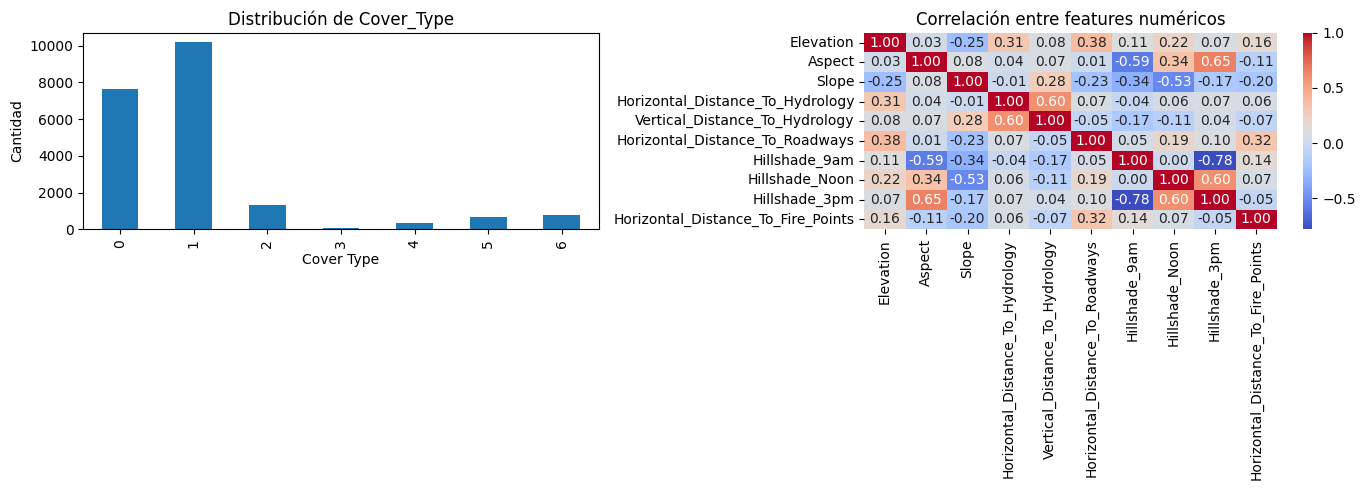

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Cover_Type"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Distribución de Cover_Type")
axes[0].set_xlabel("Cover Type")
axes[0].set_ylabel("Cantidad")

numeric_feature_cols = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]
sns.heatmap(df[numeric_feature_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlación entre features numéricos")

plt.tight_layout()
plt.show()

## 3. Preparación de datos para entrenamiento

In [30]:
NUMERIC_FEATURES = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]
CATEGORICAL_FEATURES = ["Wilderness_Area", "Soil_Type"]
TARGET = "Cover_Type"

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

# Split en 3: 60% train, 20% validación, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full,
)
print(f"Train: {len(X_train)} | Validación: {len(X_val)} | Test: {len(X_test)}")


def make_preprocessor():
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ])

Train: 12572 | Validación: 4191 | Test: 4191


## 4. Entrenamiento de redes neuronales

Se entrenan 5 modelos MLP con diferentes arquitecturas variando capas y neuronas:

| Modelo | Arquitectura | Descripción |
|--------|-------------|-------------|
| `mlp_small` | (64,) | 1 capa, 64 neuronas |
| `mlp_medium` | (128, 64) | 2 capas, 128→64 neuronas |
| `mlp_large` | (256, 128, 64) | 3 capas, 256→128→64 neuronas |
| `mlp_deep` | (128, 128, 64, 32) | 4 capas, 128→128→64→32 neuronas |
| `mlp_wide` | (512, 256) | 2 capas anchas, 512→256 neuronas |

In [31]:
architectures = {
    "mlp_small":  (64,),
    "mlp_medium": (128, 64),
    "mlp_large":  (256, 128, 64),
    "mlp_deep":   (128, 128, 64, 32),
    "mlp_wide":   (512, 256),
}

results = {}

for name, hidden_layers in architectures.items():
    print(f"\n{'='*60}")
    print(f"Entrenando: {name} | Arquitectura: {hidden_layers}")
    print("=" * 60)

    pipeline = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            max_iter=500,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
        )),
    ])
    pipeline.fit(X_train, y_train)

    # Evaluar en validación
    y_pred_val = pipeline.predict(X_val)
    acc_val = accuracy_score(y_val, y_pred_val)

    # Evaluar en test
    y_pred_test = pipeline.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred_test)

    results[name] = {
        "accuracy_val": acc_val,
        "accuracy_test": acc_test,
        "architecture": hidden_layers,
        "pipeline": pipeline,
    }

    print(f"Accuracy Validación: {acc_val:.4f}")
    print(f"Accuracy Test:       {acc_test:.4f}")
    print(f"\nClassification Report (Test):")
    print(classification_report(y_test, y_pred_test))


Entrenando: mlp_small | Arquitectura: (64,)
Accuracy Validación: 0.7831
Accuracy Test:       0.7810

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.78      0.77      0.78      1525
           1       0.80      0.82      0.81      2038
           2       0.75      0.82      0.79       260
           3       0.67      0.50      0.57        16
           4       0.53      0.26      0.35        70
           5       0.48      0.46      0.47       131
           6       0.90      0.75      0.82       151

    accuracy                           0.78      4191
   macro avg       0.70      0.63      0.65      4191
weighted avg       0.78      0.78      0.78      4191


Entrenando: mlp_medium | Arquitectura: (128, 64)
Accuracy Validación: 0.8848
Accuracy Test:       0.8762

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1525
           1       0.90  

## 5. Comparación de resultados

    Modelo       Arquitectura  Acc. Validación  Acc. Test
  mlp_wide         (512, 256)         0.921260   0.909091
 mlp_large     (256, 128, 64)         0.903842   0.897161
  mlp_deep (128, 128, 64, 32)         0.908136   0.896445
mlp_medium          (128, 64)         0.884753   0.876163
 mlp_small              (64,)         0.783107   0.780959


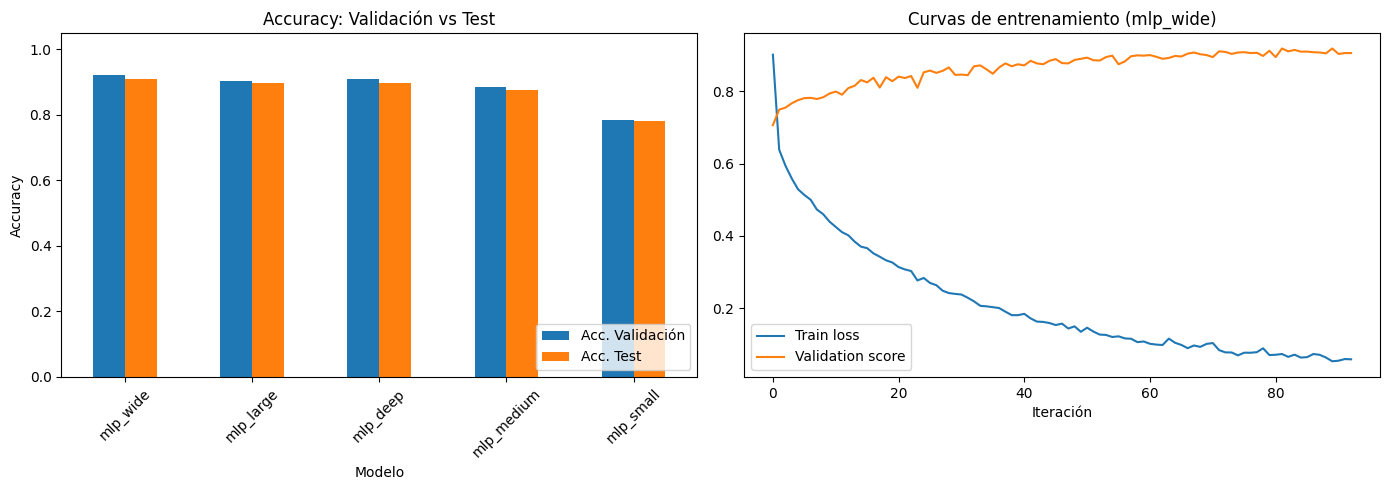

In [32]:
results_df = pd.DataFrame([
    {
        "Modelo": name,
        "Arquitectura": str(info["architecture"]),
        "Acc. Validación": info["accuracy_val"],
        "Acc. Test": info["accuracy_test"],
    }
    for name, info in results.items()
]).sort_values("Acc. Test", ascending=False)

print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy validación vs test por modelo
results_df.plot(x="Modelo", y=["Acc. Validación", "Acc. Test"], kind="bar", ax=axes[0])
axes[0].set_title("Accuracy: Validación vs Test")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(loc="lower right")

# Curvas de pérdida del mejor modelo
best_model_name = results_df.iloc[0]["Modelo"]
best_clf = results[best_model_name]["pipeline"].named_steps["classifier"]
axes[1].plot(best_clf.loss_curve_, label="Train loss")
if best_clf.validation_scores_:
    axes[1].plot(best_clf.validation_scores_, label="Validation score")
axes[1].set_title(f"Curvas de entrenamiento ({best_model_name})")
axes[1].set_xlabel("Iteración")
axes[1].legend()

plt.tight_layout()
plt.show()

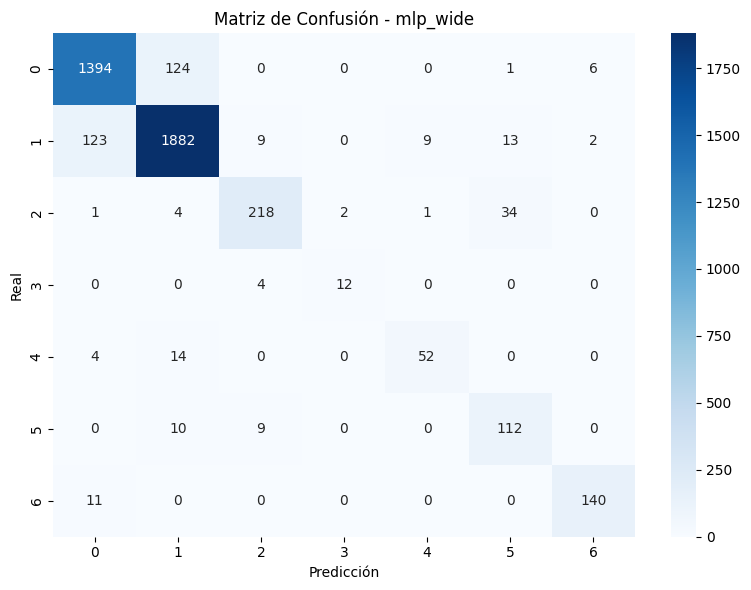

In [33]:
# Matriz de confusión del mejor modelo
best_pipeline = results[best_model_name]["pipeline"]
y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de Confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

## 6. Subir modelos a MinIO

In [34]:
minio_client = Minio(
    os.environ["MINIO_ENDPOINT"],
    access_key=os.environ["MINIO_ACCESS_KEY"],
    secret_key=os.environ["MINIO_SECRET_KEY"],
    secure=False,
)

bucket = os.environ.get("MINIO_BUCKET", "models")
if not minio_client.bucket_exists(bucket):
    minio_client.make_bucket(bucket)

for name, info in results.items():
    buffer = io.BytesIO()
    joblib.dump(info["pipeline"], buffer)
    buffer.seek(0)
    object_name = f"{name}.joblib"
    minio_client.put_object(bucket, object_name, buffer, length=buffer.getbuffer().nbytes)
    print(f"Subido: {object_name} ({buffer.getbuffer().nbytes / 1024:.1f} KB)")

print(f"\n{len(results)} modelos subidos a MinIO (bucket: {bucket})")
print("Usa POST /reload en la API para cargar los nuevos modelos.")

Subido: mlp_small.joblib (105.1 KB)
Subido: mlp_medium.joblib (379.9 KB)
Subido: mlp_large.joblib (1308.4 KB)
Subido: mlp_deep.joblib (809.5 KB)
Subido: mlp_wide.joblib (3771.6 KB)

5 modelos subidos a MinIO (bucket: models)
Usa POST /reload en la API para cargar los nuevos modelos.
